# EDA 1. Consum energetic orar - reteaua PJM (USA)

**Set de date:** `PJME_hourly.csv` - consumul orar in megawati al regiunii PJM East (Pennsylvania-New Jersey-Maryland), una dintre cele mai mari piete energetice angro din SUA.

**Scop:** intelegerea distributiei, sezonalitatii si tiparelor temporale ale consumului inainte de a construi modele predictive.

## Setup

In [1]:
import sys
from pathlib import Path

# Adaugam radacina proiectului in PYTHONPATH ca sa importam din src/
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_processing.loader import load_consum_usa
from src.utils.plotting import (
    setup_style,
    plot_timeseries_resampled,
    plot_distribution,
    plot_seasonal_patterns,
)

setup_style()

## 1. Incarcarea datelor

Fisierul are doua coloane: `Datetime` (timestamp orar) si `PJME_MW` (puterea consumata in MW). Functia `load_consum_usa()` parseaza timestamp-ul si il seteaza ca index, apoi sorteaza cronologic si elimina duplicatele.

In [2]:
df = load_consum_usa()

print(f'Dimensiune: {df.shape}')
print(f'Perioada: {df.index.min()} -> {df.index.max()}')
print(f'Numar zile acoperite: {(df.index.max() - df.index.min()).days}')
df.head()

Dimensiune: (145362, 1)
Perioada: 2002-01-01 01:00:00 -> 2018-08-03 00:00:00
Numar zile acoperite: 6057


,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


**Interpretare:** datele acopera aproximativ 16 ani (2002-2018), cu o singura valoare pe ora. Aceasta granularitate este suficienta pentru forecasting pe termen scurt (ore-zile) si analiza sezonalitatii.

## 2. Statistici descriptive

In [3]:
df.describe().round(2)

,PJME_MW
count,145362.00
mean,32080.51
std,6463.87
min,14544.00
25%,27573.00
50%,31421.00
75%,35650.00
max,62009.00


**Interpretare:** consumul mediu este in jurul a 32-33 GW, cu un minim de aproximativ 14 GW (ore de noapte, vara) si un maxim de peste 60 GW (varfuri de iarna sau vara cu temperaturi extreme). Variatia este mare, deci modelul predictiv trebuie sa capteze atat tiparele zilnice cat si pe cele sezoniere.

## 3. Valori lipsa si duplicate

In [4]:
print(f'Valori lipsa:\n{df.isna().sum()}')
print(f'\nDuplicate in index: {df.index.duplicated().sum()}')

# Verificam continuitatea timestamp-urilor (orar perfect)
expected = pd.date_range(df.index.min(), df.index.max(), freq="h")
missing_hours = expected.difference(df.index)
print(f'Ore lipsa din serie: {len(missing_hours)}')

Valori lipsa:
PJME_MW    0
dtype: int64

Duplicate in index: 0
Ore lipsa din serie: 30


**Interpretare:** datele sunt curate (fara NaN), dar pot exista mici discontinuitati datorita schimbarilor de ora (DST). Daca apar lipsuri orare, le vom completa prin interpolare liniara la pasul de preprocesare.

## 4. Vizualizare seria temporala

La 145k de puncte, plotul orar este aglomerat. Agregam pe zi si pe luna pentru a vedea trendul.

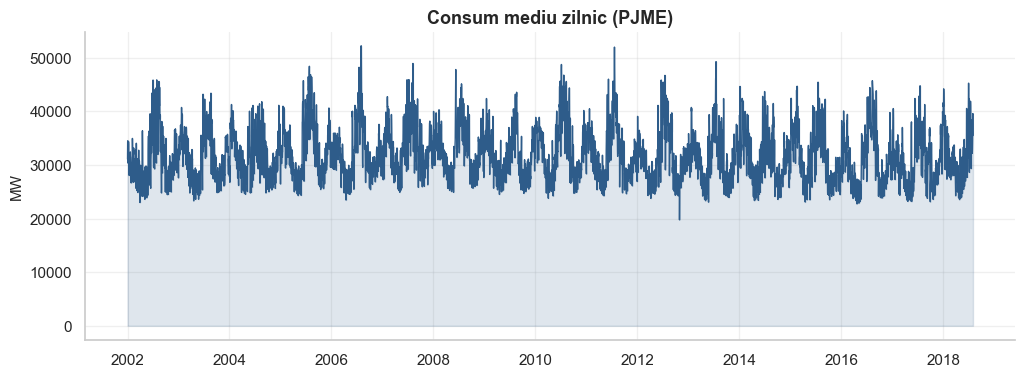

In [5]:
ax = plot_timeseries_resampled(df['PJME_MW'], rule='D', title='Consum mediu zilnic (PJME)', ylabel='MW')
plt.show()

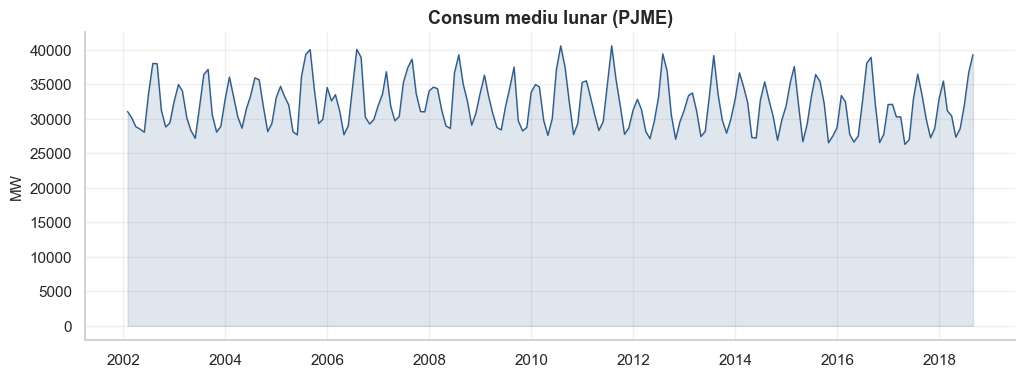

In [6]:
ax = plot_timeseries_resampled(df['PJME_MW'], rule='ME', title='Consum mediu lunar (PJME)', ylabel='MW')
plt.show()

**Interpretare:** se observa clar sezonalitatea anuala (varfuri vara - aer conditionat - si iarna - incalzire), precum si o usoara crestere a consumului peste ani, conforma cu cresterea populatiei si a economiei. Nu exista o tendinta brusc anormala care sa sugereze evenimente exceptionale.

## 5. Distributia valorilor

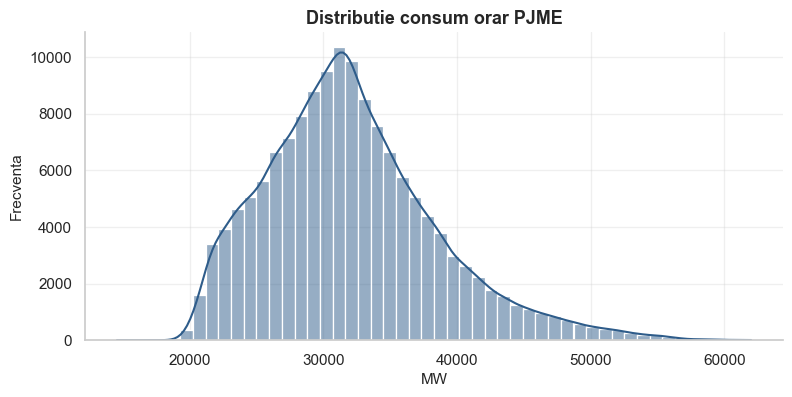

Asimetrie (skewness): 0.739
Kurtosis:              0.737


In [7]:
ax = plot_distribution(df['PJME_MW'], title='Distributie consum orar PJME', xlabel='MW')
plt.show()

print(f'Asimetrie (skewness): {df["PJME_MW"].skew():.3f}')
print(f'Kurtosis:              {df["PJME_MW"].kurt():.3f}')

**Interpretare:** distributia este usor asimetrica spre dreapta - valorile mari (varfuri de consum) sunt mai rare dar contribuie semnificativ. Pentru modele liniare poate fi util sa aplicam o transformare logaritmica; pentru modele bazate pe arbori (RF, XGBoost) nu este necesar.

## 6. Tipare sezoniere

Cele patru subgrafice arata media consumului grupata pe ora a zilei, zi a saptamanii, luna a anului si an.

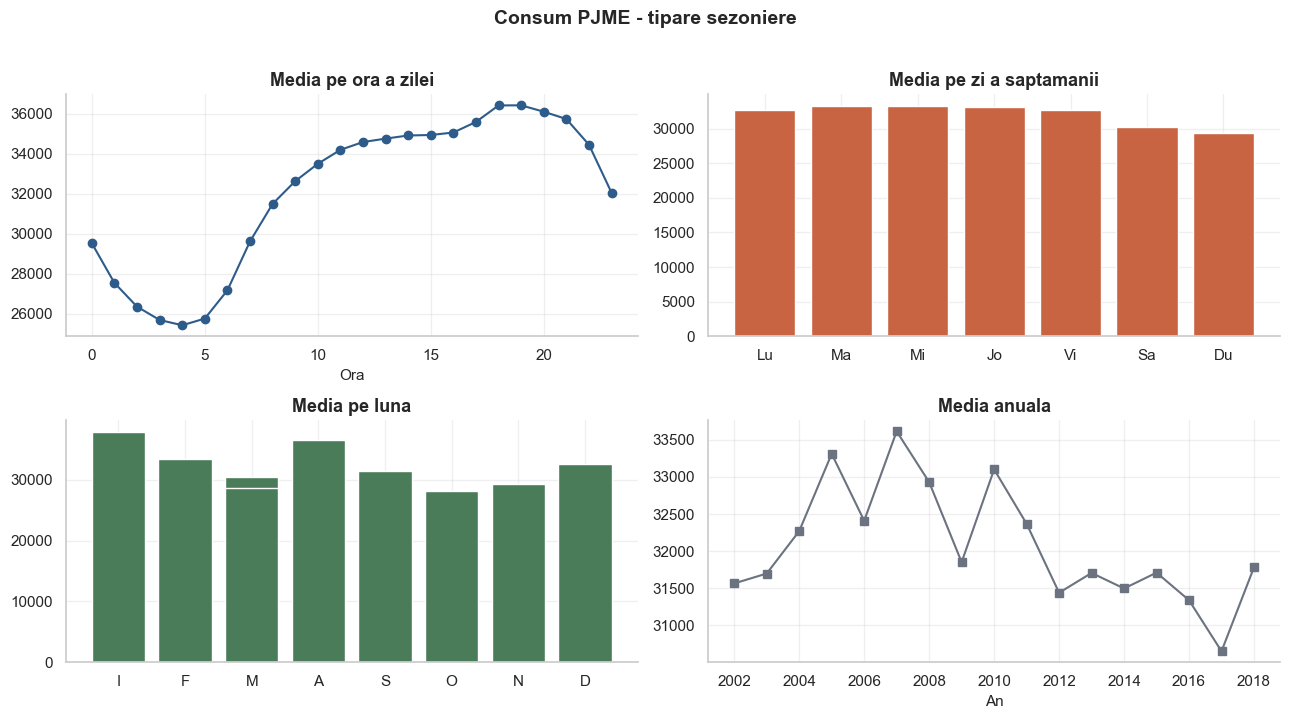

In [8]:
fig, axes = plot_seasonal_patterns(df['PJME_MW'], title='Consum PJME - tipare sezoniere')
plt.show()

**Interpretare detaliata:**

- **Pe ora:** consumul minim este in jurul orei 04:00 si creste pana la varful de seara (ora 18-20). Acest lucru reflecta ciclul activitatii umane si iluminatului.
- **Pe zi:** zilele lucratoare au consum mai mare decat weekend-ul, ceea ce confirma componenta industriala/comerciala.
- **Pe luna:** varfuri in iulie-august (climatizare) si decembrie-ianuarie (incalzire), minim primavara/toamna.
- **Pe an:** trend usor crescator pana in 2007, apoi platou - probabil datorita cresterii eficientei energetice si a recesiunii din 2008.

Aceste tipare sunt features critice pentru modelul predictiv. La pasul de feature engineering vom crea coloane derivate: `hour`, `dayofweek`, `month`, `year`, `is_weekend`.

## 7. Concluzii si pasi urmatori

**Ce am invatat:**
1. Datele acopera 2002-2018, granularitate orara, fara lipsuri majore.
2. Consumul prezinta sezonalitate puternica pe trei niveluri: zilnic, saptamanal, anual.
3. Distributia este usor asimetrica, fara outliers extremi.

**Pasi urmatori:**
- Feature engineering: extragere features temporale, lag-uri (t-1, t-24, t-168), rolling means.
- Test/train split respectand cronologia (nu shuffle).
- Antrenare modele baseline (Linear Regression) si avansate (Random Forest, XGBoost, LSTM).
- Comparare metrici: RMSE, MAE, MAPE.

Acest set este excelent pentru forecasting deoarece are istoric lung si tipare clare.